In [1]:
!pip install tensorflow
import tensorflow as tf

# 1. Detect and connect to the TPU
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("Running on TPU:", resolver.master())
except ValueError:
    strategy = tf.distribute.get_strategy() # Fallback to CPU/GPU if TPU is unavailable
    print("Not connected to a TPU runtime.")
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50

Not connected to a TPU runtime.


In [2]:
!pip install medmnist

In [3]:
import medmnist
from medmnist import BloodMNIST

# Load the splits
train_ds = BloodMNIST(split='train', download=True)
val_ds = BloodMNIST(split='val', download=True)
test_ds = BloodMNIST(split='test', download=True)

# Put the data into the requested variable format
dataset = (train_ds, val_ds, test_ds)
info = train_ds.info

In [5]:
import gc # Garbage collector to clear RAM

# Clear any previous memory
tf.keras.backend.clear_session()
gc.collect()

IMG_SIZE = 64
BATCH_SIZE = 64    # Dropped from 128 to 64 to prevent OOM crashes

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = image / 255.0
    label = tf.cast(tf.squeeze(label), tf.int32)
    return image, label

# Convert MedMNIST datasets to tf.data.Dataset
train_ds_tf = tf.data.Dataset.from_tensor_slices((train_ds.imgs, train_ds.labels))
val_ds_tf = tf.data.Dataset.from_tensor_slices((val_ds.imgs, val_ds.labels))
test_ds_tf = tf.data.Dataset.from_tensor_slices((test_ds.imgs, test_ds.labels))

# Reduced shuffle buffer to 500 to save System RAM
train_ds = (train_ds_tf
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(500)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = val_ds_tf.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_tf.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [6]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import medmnist # Re-import medmnist to ensure medmnist.INFO is available

# Define NUM_CLASSES (hardcoded due to persistent KeyError in medmnist.INFO lookup)
NUM_CLASSES = 8 # BloodMNIST has 8 classes: basophil, eosinophil, erythroblast, ig, lymphocyte, monocyte, neutrophil, platelet

def build_custom_cnn():
    model = Sequential([
        # Block 1: Focus on low-level textures
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.2),

        # Block 2: Middle-level features
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.3),

        # Block 3: High-level features
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling2D(),

        # Dense Head
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Define callbacks_cnn
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# Train for 30 epochs without steps_per_epoch
cnn_model = build_custom_cnn()
cnn_history = cnn_model.fit(train_ds, epochs=30, validation_data=val_ds, callbacks=callbacks_cnn)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.7765 - loss: 0.6558 - val_accuracy: 0.1887 - val_loss: 5.1189
Epoch 2/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8589 - loss: 0.4058 - val_accuracy: 0.2850 - val_loss: 4.9379
Epoch 3/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8832 - loss: 0.3294 - val_accuracy: 0.2155 - val_loss: 9.6707
Epoch 4/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8984 - loss: 0.2940 - val_accuracy: 0.8645 - val_loss: 0.4070
Epoch 5/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9087 - loss: 0.2604 - val_accuracy: 0.6244 - val_loss: 1.1819
Epoch 6/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9147 - loss: 0.2499 - val_accuracy: 0.8516 - val_loss: 0.4234
Epoch 7/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9255 - loss: 0.2113 - val_accuracy: 0.7570 - val_loss: 1.0194
Epoch 8/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9265 - loss: 0.2115 - val_acc

In [7]:
# Wrap the creation inside the strategy scope
with strategy.scope():
    cnn_model = build_custom_cnn()
    # The model is now officially 'residing' on the TPU memory

# You can run .fit() OUTSIDE the scope to keep the code clean
cnn_history = cnn_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks_cnn
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.7867 - loss: 0.6541 - val_accuracy: 0.1379 - val_loss: 4.6681
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8582 - loss: 0.3994 - val_accuracy: 0.2202 - val_loss: 8.8348
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8828 - loss: 0.3273 - val_accuracy: 0.5590 - val_loss: 1.8395
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8966 - loss: 0.2915 - val_accuracy: 0.6782 - val_loss: 1.3070
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9135 - loss: 0.2530 - val_accuracy: 0.8744 - val_loss: 0.3329
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9183 - loss: 0.2309 - val_accuracy: 0.7751 - val_loss: 0.6946
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9222 - loss: 0.2231 - val_accuracy: 0.7792 - val_loss: 0.9093
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9290 - loss: 0.1983 - val_accuracy: 0.56

In [10]:
# Define callbacks_resnet (assuming similar to cnn_callbacks for now)
callbacks_resnet = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

# Define CLASS_NAMES from the dataset info
CLASS_NAMES = list(info['label'].values())

def build_resnet():
    with strategy.scope():
        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )

        # Freeze initial layers for feature extraction
        base_model.trainable = False

        # Add custom classification head
        model = Sequential([
            base_model,
            GlobalAveragePooling2D(),
            Dense(256, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),
            Dense(NUM_CLASSES, activation='softmax')
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    return model, base_model


# Wrap the creation and the second compilation (fine-tuning) inside the scope
resnet_model, base_model = build_resnet()

print('\n--- ResNet50 Phase 1 ---')
resnet_model.fit(train_ds, epochs=10, validation_data=val_ds, callbacks=callbacks_resnet)

# IMPORTANT: Re-compiling for Phase 2 must also be in the scope
with strategy.scope():
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    resnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print('\n--- ResNet50 Phase 2 ---')
resnet_model.fit(train_ds, epochs=10, validation_data=val_ds, callbacks=callbacks_resnet)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step

--- ResNet50 Phase 1 ---
Epoch 1/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.6284 - loss: 1.0368 - val_accuracy: 0.1822 - val_loss: 2.4873
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6964 - loss: 0.8519 - val_accuracy: 0.1822 - val_loss: 2.9121
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7085 - loss: 0.8116 - val_accuracy: 0.5064 - val_loss: 1.3165
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7160 - loss: 0.7885 - val_accuracy: 0.5053 - val_loss: 2.5509
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7258 - loss: 0.7640 - val_accuracy: 0.3744 - val_loss: 3.7567
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7230 - loss: 0.7618 - val_accuracy: 0.4936 - val_loss: 2.5136
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7298 - loss: 0.7510 - val_accuracy: 0.4609 - val_loss: 2.0638
Epoch 8/10
187/187 

In [11]:
cnn_loss,    cnn_acc    = cnn_model.evaluate(test_ds)
resnet_loss, resnet_acc = resnet_model.evaluate(test_ds)
print(f'\nCustom CNN  — Test Accuracy: {cnn_acc*100:.2f}%')
print(f'ResNet50    — Test Accuracy: {resnet_acc*100:.2f}%')


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8743 - loss: 0.3582
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.7466 - loss: 0.7022

Custom CNN  — Test Accuracy: 87.43%
ResNet50    — Test Accuracy: 74.66%


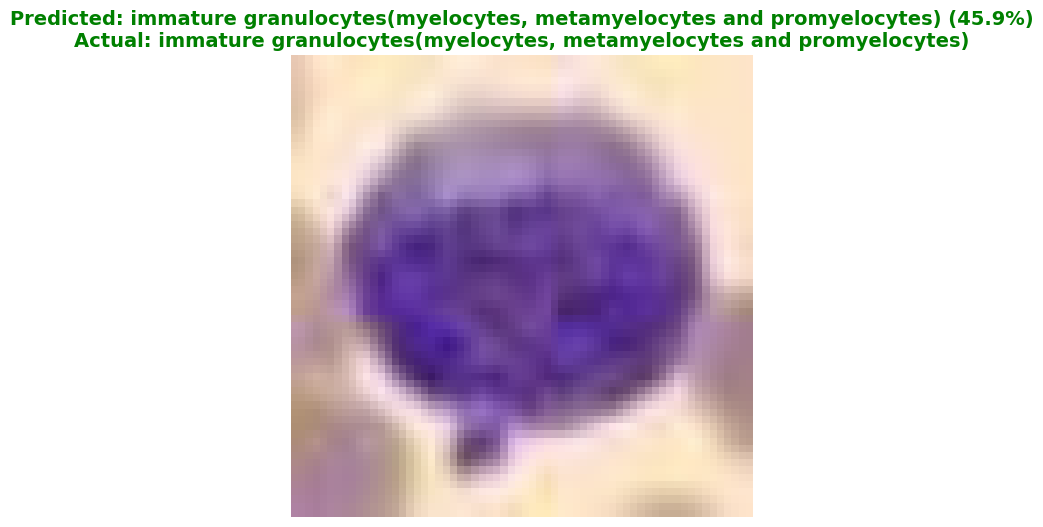


Top-3 predictions:
  immature granulocytes(myelocytes, metamyelocytes and promyelocytes): 45.9%
  basophil: 28.8%
  monocyte: 18.9%


In [12]:
import numpy as np
import matplotlib.pyplot as plt

for images, labels in test_ds.take(1):
    sample_image = images[0]
    true_label   = int(labels[0].numpy())

input_image  = tf.expand_dims(sample_image, 0)
preds        = resnet_model.predict(input_image, verbose=0)[0]
predicted_idx = int(np.argmax(preds))
confidence    = float(preds[predicted_idx])

predicted_class = CLASS_NAMES[predicted_idx]
true_class      = CLASS_NAMES[true_label]
color = 'green' if predicted_idx == true_label else 'red'

plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(
    f'Predicted: {predicted_class} ({confidence*100:.1f}%)\nActual: {true_class}',
    color=color, fontsize=14, fontweight='bold'
)
plt.axis('off')
plt.show()

print('\nTop-3 predictions:')
top3_idx = np.argsort(preds)[::-1][:3]
for idx in top3_idx:
    print(f'  {CLASS_NAMES[idx]}: {preds[idx]*100:.1f}%')
